# Modelos no lineales: Random Forest y XGBoost

**TFM:** estimación de riesgo de mercado — target `target_risk_20d`.

Evaluamos árboles con los **mismos datos, splits y métricas** que el Notebook 04.

- **No** se usa test para elegir hiperparámetros ni thresholds.
- **No** SHAP ni dashboard en esta fase.


## 0. Librerías, rutas y constantes


In [ ]:
%matplotlib inline

from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as exc:
    xgb = None
    XGBOOST_AVAILABLE = False
    _xgb_import_error = str(exc)

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

MODELING_DIR = PROJECT_ROOT / "data" / "processed" / "modeling"
REPORTS_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_risk_20d"
RANDOM_STATE = 42
THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)

LEVEL_FEATURES = [
    "sp500_close", "sp500_rolling_max_252d", "sp500_ma_50", "sp500_ma_200",
]

print("XGBoost disponible:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("Instalar con: pip install xgboost")
    print("Si falla en macOS: brew install libomp")
    if "_xgb_import_error" in dir():
        print("Detalle:", _xgb_import_error[:200])


XGBoost disponible: True


## 1. Cargar datos y definir variantes de features


In [2]:
FEATURE_COLS = (
    MODELING_DIR / "feature_columns.txt"
).read_text(encoding="utf-8").strip().split("\n")

FEATURE_VARIANTS = {
    "all_features": FEATURE_COLS,
    "reduced_no_level_features": [c for c in FEATURE_COLS if c not in LEVEL_FEATURES],
}

df_train = pd.read_csv(MODELING_DIR / "train.csv", parse_dates=["date"])
df_val = pd.read_csv(MODELING_DIR / "validation.csv", parse_dates=["date"])
df_test = pd.read_csv(MODELING_DIR / "test.csv", parse_dates=["date"])

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]
X_val = df_val[FEATURE_COLS]
y_val = df_val[TARGET_COL]
X_test = df_test[FEATURE_COLS]
y_test = df_test[TARGET_COL]

X_train_var = {k: df_train[v] for k, v in FEATURE_VARIANTS.items()}
X_val_var = {k: df_val[v] for k, v in FEATURE_VARIANTS.items()}
X_test_var = {k: df_test[v] for k, v in FEATURE_VARIANTS.items()}

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Train:", len(df_train), "| Val:", len(df_val), "| Test:", len(df_test))
print("scale_pos_weight (XGBoost):", round(scale_pos_weight, 4))


Train: 6302 | Val: 986 | Test: 1560
scale_pos_weight (XGBoost): 2.9265


## 2. Funciones de evaluación y selección de threshold

Mismas métricas que Notebook 04. El threshold optimizado se elige **solo en validation**.


In [3]:
def evaluate_classifier(model_name, split_name, y_true, y_pred, y_proba=None):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out = {
        "modelo": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "roc_auc": np.nan, "pr_auc": np.nan,
    }
    if y_proba is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
        out["pr_auc"] = average_precision_score(y_true, y_proba)
    return out


def make_tree_row(modelo, variant, hyperparams, thr_type, thr, split, y, pred, proba):
    row = evaluate_classifier(modelo, split, y, pred, proba)
    row.update({
        "variant_features": variant,
        "hyperparams": hyperparams,
        "threshold_type": thr_type,
        "threshold": thr,
    })
    return row


def find_best_threshold_f1(y_true, y_proba, grid=THRESHOLD_GRID):
    best_thr, best_score = grid[0], (-1.0, -1.0, -1.0)
    for thr in grid:
        pred = (y_proba >= thr).astype(int)
        score = (
            f1_score(y_true, pred, zero_division=0),
            precision_score(y_true, pred, zero_division=0),
            thr,
        )
        if score > best_score:
            best_score, best_thr = score, thr
    return float(best_thr)


def eval_model_all_splits(modelo, variant, hyperparams, model, Xtr, Xva, Xte, ytr, yva, yte, store):
    proba = {
        "train": model.predict_proba(Xtr)[:, 1],
        "validation": model.predict_proba(Xva)[:, 1],
        "test": model.predict_proba(Xte)[:, 1],
    }
    best_thr = find_best_threshold_f1(yva, proba["validation"])
    store[(modelo, variant, hyperparams)] = {
        "model": model, "proba": proba, "best_threshold": best_thr,
        "feature_cols": list(Xtr.columns),
    }
    rows = []
    for thr_type, thr in [("fixed_0.5", 0.5), ("optimized_val_f1", best_thr)]:
        for split, y, p in [
            ("train", ytr, proba["train"]),
            ("validation", yva, proba["validation"]),
            ("test", yte, proba["test"]),
        ]:
            pred = (p >= thr).astype(int)
            rows.append(make_tree_row(modelo, variant, hyperparams, thr_type, thr, split, y, pred, p))
    return rows

print("Funciones listas.")


Funciones listas.


## 3. Random Forest — búsqueda en validation

Grid pequeño: `n_estimators` × `max_depth` × `min_samples_leaf` × variante de features.


In [4]:
RF_PARAM_GRID = {
    "n_estimators": [300, 500],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [20, 50],
}

tree_selection_rows = []
rf_artifacts = {}

for variant_name in FEATURE_VARIANTS:
    Xtr, Xva, Xte = X_train_var[variant_name], X_val_var[variant_name], X_test_var[variant_name]
    for n_est, md, msl in product(
        RF_PARAM_GRID["n_estimators"],
        RF_PARAM_GRID["max_depth"],
        RF_PARAM_GRID["min_samples_leaf"],
    ):
        hp = f"n_estimators={n_est};max_depth={md};min_samples_leaf={msl};class_weight=balanced_subsample"
        rf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=md,
            min_samples_leaf=msl,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        rf.fit(Xtr, y_train)
        rows = eval_model_all_splits(
            "RandomForest", variant_name, hp, rf,
            Xtr, Xva, Xte, y_train, y_val, y_test, rf_artifacts,
        )
        tree_selection_rows.extend(rows)

print("Configs RF evaluadas:", len(rf_artifacts))
display(pd.DataFrame(tree_selection_rows).head(4))


Configs RF evaluadas: 24


,modelo,split,accuracy,precision,recall,f1,tn,fp,fn,tp,roc_auc,pr_auc,variant_features,hyperparams,threshold_type,threshold
0,RandomForest,train,0.836560,0.641835,0.810592,0.716410,3971,726,304,1301,0.901692,0.788109,all_features,n_estimators=300;max_depth=3;min_samples_leaf=...,fixed_0.5,0.50
1,RandomForest,validation,0.791075,0.309783,0.419118,0.356250,723,127,79,57,0.634477,0.261124,all_features,n_estimators=300;max_depth=3;min_samples_leaf=...,fixed_0.5,0.50
2,RandomForest,test,0.657051,0.445570,0.783964,0.568200,673,438,97,352,0.774071,0.636096,all_features,n_estimators=300;max_depth=3;min_samples_leaf=...,fixed_0.5,0.50
3,RandomForest,train,0.813234,0.595450,0.831776,0.694047,3790,907,270,1335,0.901692,0.788109,all_features,n_estimators=300;max_depth=3;min_samples_leaf=...,optimized_val_f1,0.45


## 4. XGBoost — búsqueda en validation (si está instalado)

Si `xgboost` no está disponible, esta celda se salta sin romper el notebook.


In [5]:
xgb_artifacts = {}

if XGBOOST_AVAILABLE:
    XGB_PARAM_GRID = {
        "n_estimators": [200, 400],
        "max_depth": [2, 3],
        "learning_rate": [0.03, 0.05],
    }
    for variant_name in FEATURE_VARIANTS:
        Xtr, Xva, Xte = X_train_var[variant_name], X_val_var[variant_name], X_test_var[variant_name]
        for n_est, md, lr in product(
            XGB_PARAM_GRID["n_estimators"],
            XGB_PARAM_GRID["max_depth"],
            XGB_PARAM_GRID["learning_rate"],
        ):
            hp = f"n_estimators={n_est};max_depth={md};lr={lr};subsample=0.8;colsample_bytree=0.8"
            model = xgb.XGBClassifier(
                n_estimators=n_est,
                max_depth=md,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            model.fit(Xtr, y_train, verbose=False)
            rows = eval_model_all_splits(
                "XGBoost", variant_name, hp, model,
                Xtr, Xva, Xte, y_train, y_val, y_test, xgb_artifacts,
            )
            tree_selection_rows.extend(rows)
    print("Configs XGBoost evaluadas:", len(xgb_artifacts))
else:
    print("XGBoost no instalado — omitido. Ejecutar: pip install xgboost")


Configs XGBoost evaluadas: 16


## 5. Selección de mejores modelos (F1 en validation, threshold optimizado)


In [6]:
tree_df = pd.DataFrame(tree_selection_rows)

def pick_best(model_name, artifacts):
    sub = tree_df[
        (tree_df["modelo"] == model_name)
        & (tree_df["split"] == "validation")
        & (tree_df["threshold_type"] == "optimized_val_f1")
    ].sort_values(["f1", "precision", "threshold"], ascending=[False, False, False])
    if sub.empty:
        return None, None
    best = sub.iloc[0]
    key = (model_name, best["variant_features"], best["hyperparams"])
    return best, artifacts[key]

best_rf_row, best_rf_art = pick_best("RandomForest", rf_artifacts)
best_xgb_row, best_xgb_art = (None, None)
if XGBOOST_AVAILABLE:
    best_xgb_row, best_xgb_art = pick_best("XGBoost", xgb_artifacts)

print("=== Mejor Random Forest (validation) ===")
display(pd.DataFrame([best_rf_row]).T)
if best_xgb_row is not None:
    print("=== Mejor XGBoost (validation) ===")
    display(pd.DataFrame([best_xgb_row]).T)


=== Mejor Random Forest (validation) ===


,16
modelo,RandomForest
split,validation
accuracy,0.795132
precision,0.339806
recall,0.514706
f1,0.409357
tn,714
fp,136
fn,66
tp,70


=== Mejor XGBoost (validation) ===


,184
modelo,XGBoost
split,validation
accuracy,0.872211
precision,0.536765
recall,0.536765
f1,0.536765
tn,787
fp,63
fn,63
tp,73


## 6. Comparación con baselines del Notebook 04

Recuperamos VIX y LogReg desde los CSV guardados en Notebook 04.


In [7]:
baseline_summary = pd.read_csv(REPORTS_TABLES / "baseline_summary_val_test.csv")

compare_rows = baseline_summary.copy()
compare_rows["modelo"] = compare_rows["modelo"].astype(str)

# Mejor RF en val/test
for split in ["validation", "test"]:
    r = tree_df[
        (tree_df["modelo"] == "RandomForest")
        & (tree_df["variant_features"] == best_rf_row["variant_features"])
        & (tree_df["hyperparams"] == best_rf_row["hyperparams"])
        & (tree_df["threshold_type"] == "optimized_val_f1")
        & (tree_df["split"] == split)
    ].iloc[0]
    compare_rows = pd.concat([compare_rows, pd.DataFrame([{
        "modelo": "RandomForest (best)",
        "split": split,
        "f1": r["f1"], "precision": r["precision"],
        "recall": r["recall"], "pr_auc": r["pr_auc"],
    }])], ignore_index=True)

if best_xgb_row is not None:
    for split in ["validation", "test"]:
        r = tree_df[
            (tree_df["modelo"] == "XGBoost")
            & (tree_df["variant_features"] == best_xgb_row["variant_features"])
            & (tree_df["hyperparams"] == best_xgb_row["hyperparams"])
            & (tree_df["threshold_type"] == "optimized_val_f1")
            & (tree_df["split"] == split)
        ].iloc[0]
        compare_rows = pd.concat([compare_rows, pd.DataFrame([{
            "modelo": "XGBoost (best)",
            "split": split,
            "f1": r["f1"], "precision": r["precision"],
            "recall": r["recall"], "pr_auc": r["pr_auc"],
        }])], ignore_index=True)

model_comparison = compare_rows[
    compare_rows["modelo"].isin([
        "VIX rule",
        "LogReg best all_features",
        "LogReg best reduced_no_level",
        "RandomForest (best)",
    ] + (["XGBoost (best)"] if best_xgb_row is not None else []))
].round(4)

print("Comparativa validation / test:")
display(model_comparison)


Comparativa validation / test:


,modelo,split,f1,precision,recall,pr_auc,C,threshold
0,VIX rule,validation,0.3556,0.3128,0.4118,NaN,NaN,NaN
1,VIX rule,test,0.5420,0.4017,0.8330,NaN,NaN,NaN
2,LogReg best all_features,validation,0.4468,0.4315,0.4632,0.3582,0.10,0.91
3,LogReg best all_features,test,0.4384,0.2828,0.9755,0.3050,0.10,0.91
4,LogReg best reduced_no_level,validation,0.3746,0.3081,0.4779,0.2489,0.01,0.44
5,LogReg best reduced_no_level,test,0.5525,0.4106,0.8441,0.6309,0.01,0.44
6,RandomForest (best),validation,0.4094,0.3398,0.5147,0.2982,NaN,NaN
7,RandomForest (best),test,0.5198,0.3806,0.8196,0.6290,NaN,NaN
8,XGBoost (best),validation,0.5368,0.5368,0.5368,0.4363,NaN,NaN
9,XGBoost (best),test,0.4923,0.4839,0.5011,0.5400,NaN,NaN


## 7. Guardar tablas y importancias de variables


In [8]:
COL_ORDER = [
    "modelo", "variant_features", "hyperparams", "threshold_type", "threshold", "split",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp",
]
tree_df_out = tree_df[COL_ORDER].round(4)
tree_df_out.to_csv(REPORTS_TABLES / "tree_model_results.csv", index=False)
tree_df_out[tree_df_out["split"] == "validation"].to_csv(
    REPORTS_TABLES / "tree_model_selection.csv", index=False
)
model_comparison.to_csv(REPORTS_TABLES / "model_comparison_summary.csv", index=False)

# Importancia RF
rf_model = best_rf_art["model"]
rf_imp = pd.DataFrame({
    "feature": best_rf_art["feature_cols"],
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)
rf_imp.to_csv(REPORTS_TABLES / "random_forest_feature_importance.csv", index=False)

if best_xgb_art is not None:
    xgb_model = best_xgb_art["model"]
    xgb_imp = pd.DataFrame({
        "feature": best_xgb_art["feature_cols"],
        "importance": xgb_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    xgb_imp.to_csv(REPORTS_TABLES / "xgboost_feature_importance.csv", index=False)

print("Tablas guardadas en reports/tables/")
display(rf_imp.head(10))


Tablas guardadas en reports/tables/


,feature,importance
1,vix,0.143094
12,sp500_vol_60d_ann,0.133779
21,vix_ma_20,0.123011
14,sp500_drawdown_252d,0.075791
13,sp500_rolling_max_252d,0.066359
10,sp500_vol_20d,0.065232
18,sp500_dist_ma200,0.063578
11,sp500_vol_20d_ann,0.058227
16,sp500_ma_200,0.057546
15,sp500_ma_50,0.038268


## 8. Figuras: matrices de confusión, ROC/PR


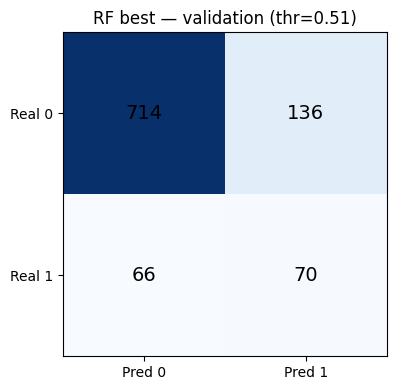

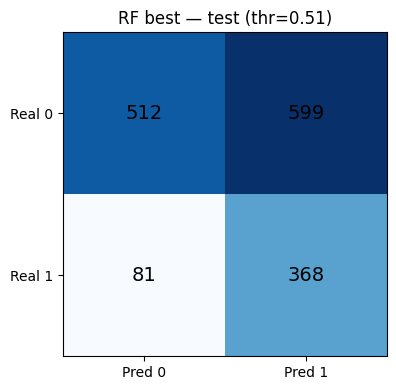

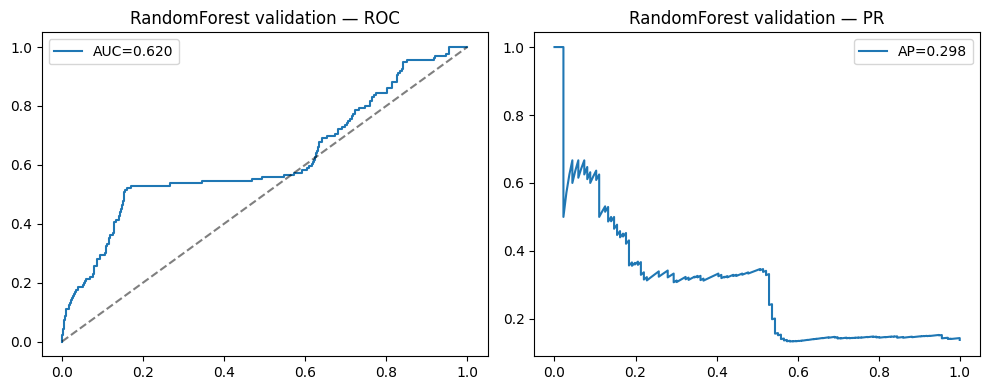

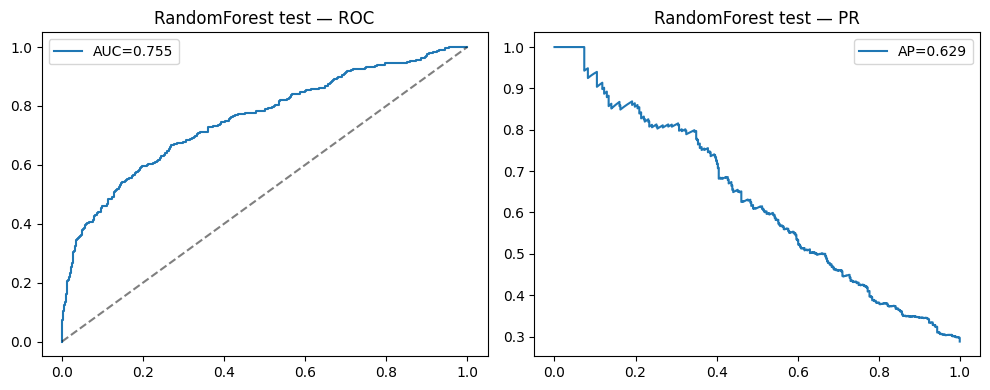

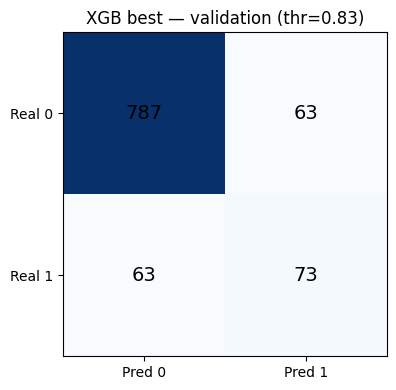

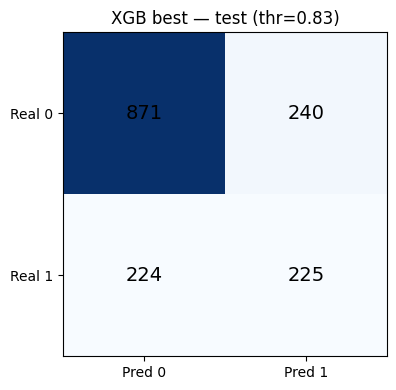

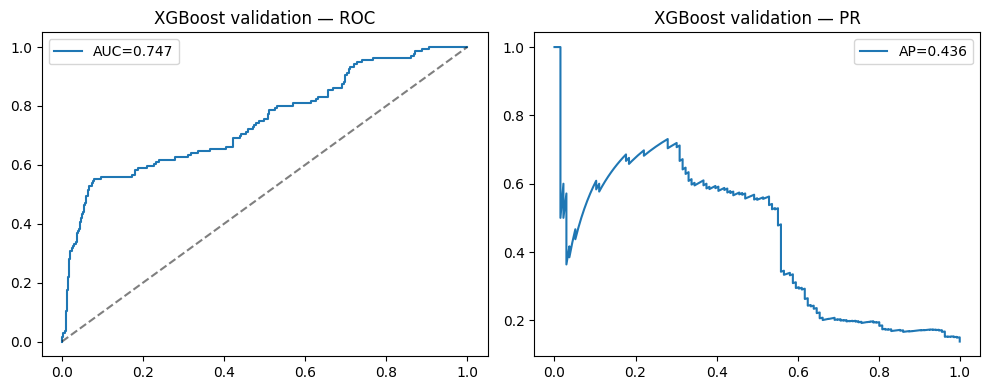

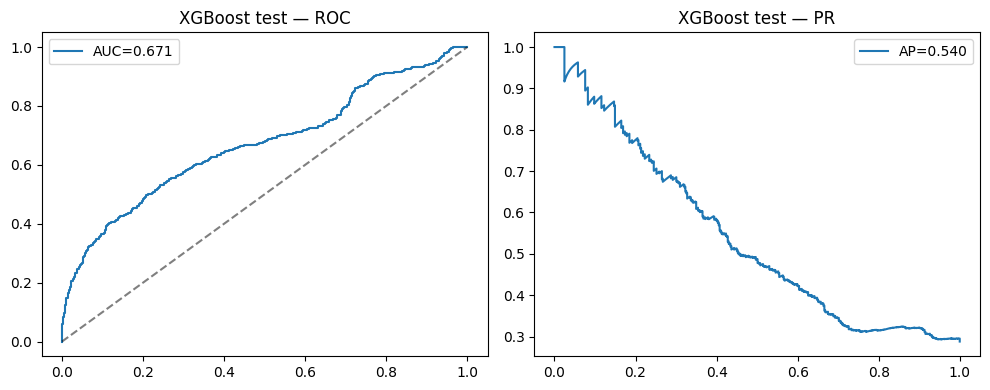

In [9]:
def plot_confusion(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["Real 0", "Real 1"])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
    plt.tight_layout()
    fig.savefig(path, dpi=120)
    plt.show()


def plot_roc_pr(y_true, y_proba, title_prefix, path):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, y_proba):.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[0].set_title(f"{title_prefix} — ROC"); axes[0].legend()
    axes[1].plot(rec, prec, label=f"AP={average_precision_score(y_true, y_proba):.3f}")
    axes[1].set_title(f"{title_prefix} — PR"); axes[1].legend()
    plt.tight_layout()
    fig.savefig(path, dpi=120)
    plt.show()


# --- Random Forest ---
rf_thr = float(best_rf_row["threshold"])
rf_proba_val = best_rf_art["proba"]["validation"]
rf_proba_test = best_rf_art["proba"]["test"]
pred_rf_val = (rf_proba_val >= rf_thr).astype(int)
pred_rf_test = (rf_proba_test >= rf_thr).astype(int)

plot_confusion(y_val, pred_rf_val, f"RF best — validation (thr={rf_thr:.2f})",
               REPORTS_FIGURES / "confusion_matrix_rf_validation.png")
plot_confusion(y_test, pred_rf_test, f"RF best — test (thr={rf_thr:.2f})",
               REPORTS_FIGURES / "confusion_matrix_rf_test.png")
plot_roc_pr(y_val, rf_proba_val, "RandomForest validation",
            REPORTS_FIGURES / "rf_roc_pr_validation.png")
plot_roc_pr(y_test, rf_proba_test, "RandomForest test",
            REPORTS_FIGURES / "rf_roc_pr_test.png")

# --- XGBoost ---
if best_xgb_art is not None:
    xgb_thr = float(best_xgb_row["threshold"])
    xgb_proba_val = best_xgb_art["proba"]["validation"]
    xgb_proba_test = best_xgb_art["proba"]["test"]
    pred_xgb_val = (xgb_proba_val >= xgb_thr).astype(int)
    pred_xgb_test = (xgb_proba_test >= xgb_thr).astype(int)
    plot_confusion(y_val, pred_xgb_val, f"XGB best — validation (thr={xgb_thr:.2f})",
                   REPORTS_FIGURES / "confusion_matrix_xgb_validation.png")
    plot_confusion(y_test, pred_xgb_test, f"XGB best — test (thr={xgb_thr:.2f})",
                   REPORTS_FIGURES / "confusion_matrix_xgb_test.png")
    plot_roc_pr(y_val, xgb_proba_val, "XGBoost validation",
                REPORTS_FIGURES / "xgb_roc_pr_validation.png")
    plot_roc_pr(y_test, xgb_proba_test, "XGBoost test",
                REPORTS_FIGURES / "xgb_roc_pr_test.png")


## 9. Conclusiones del Notebook 05

> **Nota metodológica:** la selección de hiperparámetros y thresholds se hace **solo con validation**; test es evaluación final out-of-sample.

### Mejor Random Forest (F1 validation, threshold optimizado)
- **Config:** `all_features`, `n_estimators=300`, `max_depth=5`, `min_samples_leaf=20`, threshold=**0.51**.
- **Validation:** F1 ≈ **0.409**, precision ≈ 0.340, recall ≈ 0.515, PR-AUC ≈ 0.298.
- **Test:** F1 ≈ **0.520**, precision ≈ 0.381, recall ≈ 0.820, PR-AUC ≈ **0.629**.

### Mejor XGBoost (F1 validation, threshold optimizado)
- **Config:** `all_features`, `n_estimators=400`, `max_depth=3`, `learning_rate=0.03`, `subsample=0.8`, `colsample_bytree=0.8`, threshold=**0.83**.
- **Validation:** F1 ≈ **0.537**, precision ≈ 0.537, recall ≈ 0.537, PR-AUC ≈ 0.436.
- **Test:** F1 ≈ **0.492**, precision ≈ 0.484, recall ≈ 0.501, PR-AUC ≈ **0.540**.

### Comparación con baselines (Notebook 04)

| Modelo | F1 validation | F1 test | PR-AUC test |
|--------|---------------|---------|-------------|
| VIX rule | 0.356 | **0.542** | — |
| LogReg best (`all_features`) | 0.447 | 0.438 | 0.305 |
| LogReg reduced | 0.375 | **0.553** | 0.631 |
| Random Forest (best) | 0.409 | 0.520 | **0.629** |
| **XGBoost (best)** | **0.537** | 0.492 | 0.540 |

- **Validation:** XGBoost **supera claramente** a RF (0.537 vs 0.409), a LogReg `all_features` (0.447) y a VIX (0.356). Es el mejor modelo en este split.
- **Test:** XGBoost **no supera** a VIX (0.492 vs 0.542), a LogReg reduced (0.553) ni a RF (0.520) en F1. Tampoco iguala el PR-AUC de RF/LogReg reduced (~0.63).
- **XGBoost vs RF:** mejor en validation, **peor en test** — posible sobreajuste al periodo 2016–2019 o sensibilidad al threshold alto (0.83).
- **XGBoost vs VIX:** gana en validation pero **pierde en test**; la regla VIX sigue siendo muy competitiva out-of-sample.

### Importancia de variables
- **Random Forest:** `vix`, `sp500_vol_60d_ann`, `vix_ma_20`, `sp500_drawdown_252d`, `sp500_rolling_max_252d`.
- **XGBoost:** `vix`, `vix_ma_20`, `sp500_rolling_max_252d`, `sp500_vol_60d_ann`, `sp500_dist_ma200`.

En ambos modelos domina el **VIX y la volatilidad reciente**, con señales de **drawdown/distancia a máximos** — coherente con la definición del target (estrés de riesgo futuro).

### Siguiente paso

- **`notebooks/06_error_analysis_interpretability.ipynb`**: errores, brecha validation→test, SHAP.
- **`notebooks/07_target_sensitivity_robustness.ipynb`**: sensibilidad del target (complementario).
